
# **Redes Neurais e Aprendizagem Profunda**
---


## Exemplo de Treinamento de Rede Neural

In [1]:
from __future__ import print_function
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K
from tensorflow.keras.utils import to_categorical

num_classes = 10

# input image dimensions
img_rows, img_cols = 28, 28

# the data, shuffled and split between train and test sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

if K.image_data_format() == 'channels_first':
    x_train = x_train.reshape(x_train.shape[0], 1, img_rows, img_cols)
    x_test = x_test.reshape(x_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
    x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# convert class vectors to binary class matrices
y_train_copy = y_train
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


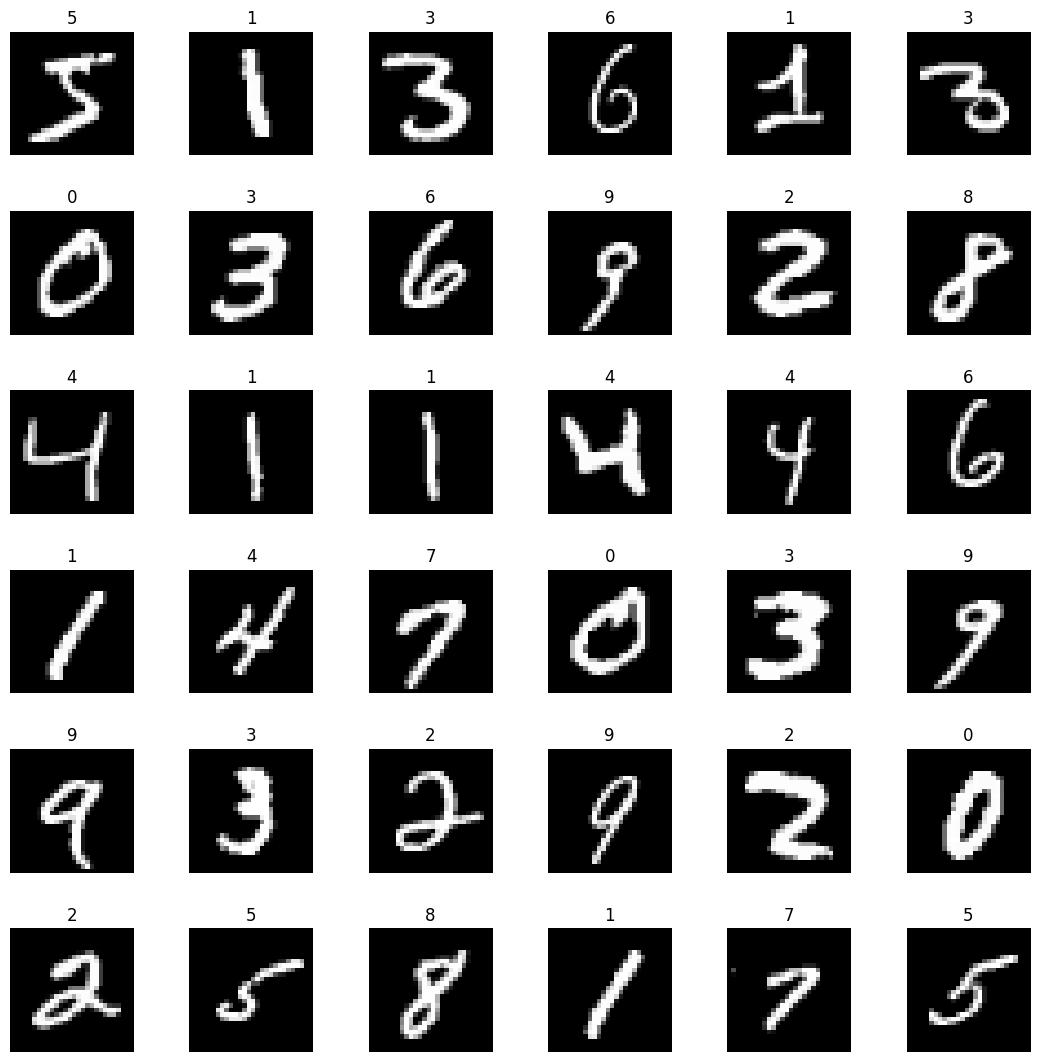

In [2]:
import matplotlib.pyplot as plt

# plot first 36 images in MNIST
fig, ax = plt.subplots(6, 6, figsize = (12, 12))
#fig.suptitle('First 36 images in MNIST')
fig.tight_layout(pad = 0.3, rect = [0, 0, 0.9, 0.9])
for x, y in [(i, j) for i in range(6) for j in range(6)]:
    ax[x, y].imshow(x_train[x + y * 6].reshape((28, 28)), cmap = 'gray')
    ax[x, y].axis('off')
    ax[x, y].set_title(y_train_copy[x + y * 6])

In [3]:

batch_size = 128
epochs = 12

model = Sequential()
model.add(keras.Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(num_classes, activation='softmax'))

model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer='SGD',
              metrics=['accuracy'])

model.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(x_test, y_test))

score = model.evaluate(x_test, y_test, verbose=0)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7654 - loss: 1.0015 - val_accuracy: 0.8863 - val_loss: 0.4242
Epoch 2/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8876 - loss: 0.3951 - val_accuracy: 0.9025 - val_loss: 0.3445
Epoch 3/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8990 - loss: 0.3487 - val_accuracy: 0.9102 - val_loss: 0.3157
Epoch 4/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9049 - loss: 0.3288 - val_accuracy: 0.9127 - val_loss: 0.3012
Epoch 5/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9083 - loss: 0.3162 - val_accuracy: 0.9164 - val_loss: 0.2945
Epoch 6/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9116 - loss: 0.3069 - val_accuracy: 0.9185 - val_loss: 0.2853
Epoch 7/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9138 - loss: 0.2989 - val_accuracy: 0.9192 - val_loss: 0.2786
Epoch 8/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9157 - loss: 0.2920 - val_accuracy: 0.

In [4]:

model1 = Sequential()
model1.add(keras.Input(shape=input_shape))
model1.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu'))
model1.add(Conv2D(64, (3, 3), activation='relu'))
model1.add(MaxPooling2D(pool_size=(2, 2)))
model1.add(Dropout(0.25))
model1.add(Flatten())
model1.add(Dense(128, activation='relu'))
model1.add(Dropout(0.5))
model1.add(Dense(num_classes, activation='softmax'))

model1.compile(loss=keras.losses.categorical_crossentropy,
              optimizer='SGD',
              metrics=['accuracy'])

model1.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(x_test, y_test))

score = model1.evaluate(x_test, y_test, verbose=0)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.6465 - loss: 1.1053 - val_accuracy: 0.9088 - val_loss: 0.3166
Epoch 2/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.8649 - loss: 0.4430 - val_accuracy: 0.9345 - val_loss: 0.2339
Epoch 3/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.8895 - loss: 0.3635 - val_accuracy: 0.9467 - val_loss: 0.1912
Epoch 4/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.9015 - loss: 0.3263 - val_accuracy: 0.9512 - val_loss: 0.1736
Epoch 5/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.9110 - loss: 0.2933 - val_accuracy: 0.9553 - val_loss: 0.1521
Epoch 6/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.9182 - loss: 0.2724 - val_accuracy: 0.9579 - val_loss: 0.1417
Epoch 7/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9234 - loss: 0.2533 - val_accuracy: 0.9615 - val_loss: 0.1345
Epoch 8/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.9266 - loss: 0.2461 - 

In [5]:

model1.compile(loss=keras.losses.categorical_crossentropy,
              optimizer='Adam',
              metrics=['accuracy'])

model1.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(x_test, y_test))

score = model1.evaluate(x_test, y_test, verbose=0)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.9451 - loss: 0.1815 - val_accuracy: 0.9797 - val_loss: 0.0636
Epoch 2/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9724 - loss: 0.0929 - val_accuracy: 0.9878 - val_loss: 0.0377
Epoch 3/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9797 - loss: 0.0676 - val_accuracy: 0.9892 - val_loss: 0.0314
Epoch 4/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.9833 - loss: 0.0557 - val_accuracy: 0.9890 - val_loss: 0.0343
Epoch 5/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.9857 - loss: 0.0461 - val_accuracy: 0.9899 - val_loss: 0.0319
Epoch 6/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.9884 - loss: 0.0382 - val_accuracy: 0.9904 - val_loss: 0.0263
Epoch 7/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.9892 - loss: 0.0342 - val_accuracy: 0.9918 - val_loss: 0.0275
Epoch 8/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.9896 - loss: 0.0336 - 